In [1]:
import model1_pipeline as m1

In [2]:
df_model1 = m1.load_model1_dataset("cmu_real.csv", "vae_synthetic.csv")

Real CMU shape: (20400, 34)
VAE shape     : (20400, 33)

Common columns count: 33
Combined shape: (40800, 34)

Label counts:
label
1    20400
0    20400
Name: count, dtype: int64


In [3]:
X, y = m1.preprocess_model1_data(df_model1)


Dropping columns: ['subject', 'sessionIndex']

Feature matrix shape: (40800, 31)
Target shape        : (40800,)

First 5 rows of X:
   H.period  DD.period.t  UD.period.t       H.t    DD.t.i    UD.t.i       H.i  \
0  0.075828     0.230816     0.149195  0.087169  0.190428  0.104034  0.066553   
1  0.101600     0.565400     0.463800  0.078400  0.089500  0.011100  0.086300   
2  0.121300     0.122600     0.001300  0.100500  0.180400  0.079900  0.074200   
3  0.126700     0.196300     0.069600  0.086900  0.145500  0.058600  0.097100   
4  0.100165     0.352343     0.247310  0.111133  0.207384  0.096943  0.086031   

     DD.i.e    UD.i.e       H.e  ...       H.a    DD.a.n    UD.a.n       H.n  \
0  0.081402  0.012955  0.092074  ...  0.141083  0.311937  0.172205  0.050864   
1  0.073100 -0.013200  0.051000  ...  0.105800  0.112500  0.006700  0.072900   
2  0.044900 -0.029300  0.058900  ...  0.091800  0.188400  0.096600  0.100500   
3  0.220400  0.123300  0.120400  ...  0.087600  0.226700  0.

In [4]:
X_train, X_test, y_train, y_test, X_train_scaled, X_test_scaled, scaler = m1.split_and_scale(X, y)


Train shape: (32640, 31)
Test shape : (8160, 31)


In [5]:
X_train_mi, X_test_mi, mi_features, mi_scores = m1.filter_mutual_info(X_train, y_train, X_test, k=10)


Top features by Mutual Information:
      feature     score
12     H.five  0.568548
30   H.Return  0.540348
0    H.period  0.534628
3         H.t  0.522866
6         H.i  0.517350
18        H.o  0.517167
27        H.l  0.512366
9         H.e  0.507391
24        H.n  0.501047
15  H.Shift.r  0.490776


In [6]:
from sklearn.preprocessing import StandardScaler

scaler_mi = StandardScaler()
X_train_mi_scaled = scaler_mi.fit_transform(X_train_mi)
X_test_mi_scaled = scaler_mi.transform(X_test_mi)

In [7]:
mi_results = m1.evaluate_classifiers(X_train_mi_scaled, X_test_mi_scaled, y_train, y_test)


Model: SVM
Accuracy:
0.7263480392156862

Confusion Matrix:
[[2959 1121]
 [1112 2968]]

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.73      0.73      4080
           1       0.73      0.73      0.73      4080

    accuracy                           0.73      8160
   macro avg       0.73      0.73      0.73      8160
weighted avg       0.73      0.73      0.73      8160

ROC-AUC: 0.7969803080545944

Model: Random Forest
Accuracy:
0.7322303921568627

Confusion Matrix:
[[2967 1113]
 [1072 3008]]

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.73      0.73      4080
           1       0.73      0.74      0.73      4080

    accuracy                           0.73      8160
   macro avg       0.73      0.73      0.73      8160
weighted avg       0.73      0.73      0.73      8160

ROC-AUC: 0.8137812680219147

Model: Logistic Regression
Accuracy:
0.6017156862745098



In [8]:
best_mi_name, best_mi_model = m1.get_best_model(mi_results)


Best model: Random Forest
Best accuracy: 0.7322303921568627


In [9]:
fpr, tpr, auc_value = m1.get_roc_data(best_mi_model, X_test_mi_scaled, y_test)


ROC-AUC: 0.8137812680219147


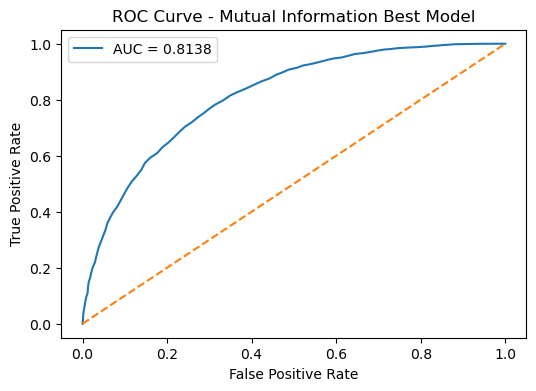

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {auc_value:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Mutual Information Best Model")
plt.legend()
plt.show()

In [11]:
X_train_anova, X_test_anova, anova_features, anova_scores = m1.filter_anova(X_train, y_train, X_test, k=10)


Top features by ANOVA F-test:
         feature       score         pvalue
11     UD.e.five  779.732284  1.363612e-169
10     DD.e.five  710.451077  7.291911e-155
21           H.a  424.354640   1.087232e-93
30      H.Return  316.461467   1.839880e-70
16  DD.Shift.r.o  270.494472   1.552360e-60
17  UD.Shift.r.o  181.974770   2.318552e-41
9            H.e  141.994012   1.140271e-32
15     H.Shift.r  130.964827   2.878910e-30
7         DD.i.e  127.815562   1.398196e-29
8         UD.i.e  118.495271   1.506461e-27


In [12]:
scaler_anova = StandardScaler()
X_train_anova_scaled = scaler_anova.fit_transform(X_train_anova)
X_test_anova_scaled = scaler_anova.transform(X_test_anova)

In [13]:
anova_results = m1.evaluate_classifiers(X_train_anova_scaled, X_test_anova_scaled, y_train, y_test)


Model: SVM
Accuracy:
0.7512254901960784

Confusion Matrix:
[[3228  852]
 [1178 2902]]

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.79      0.76      4080
           1       0.77      0.71      0.74      4080

    accuracy                           0.75      8160
   macro avg       0.75      0.75      0.75      8160
weighted avg       0.75      0.75      0.75      8160

ROC-AUC: 0.8265328839869281

Model: Random Forest
Accuracy:
0.7819852941176471

Confusion Matrix:
[[3240  840]
 [ 939 3141]]

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.79      0.78      4080
           1       0.79      0.77      0.78      4080

    accuracy                           0.78      8160
   macro avg       0.78      0.78      0.78      8160
weighted avg       0.78      0.78      0.78      8160

ROC-AUC: 0.8639682453863897

Model: Logistic Regression
Accuracy:
0.6442401960784314



In [17]:
best_anova_name, best_anova_model = m1.get_best_model(anova_results)


Best model: Random Forest
Best accuracy: 0.7819852941176471


In [14]:
X_train_rfe, X_test_rfe, rfe_features, rfe_selector = m1.wrapper_rfe(X_train, y_train, X_test, k=10)


Top features by RFE:
['H.period', 'H.t', 'H.e', 'UD.e.five', 'H.five', 'H.Shift.r', 'DD.Shift.r.o', 'H.a', 'H.n', 'H.Return']


In [15]:
scaler_rfe = StandardScaler()
X_train_rfe_scaled = scaler_rfe.fit_transform(X_train_rfe)
X_test_rfe_scaled = scaler_rfe.transform(X_test_rfe)

In [16]:
rfe_results = m1.evaluate_classifiers(X_train_rfe_scaled, X_test_rfe_scaled, y_train, y_test)


Model: SVM
Accuracy:
0.7583333333333333

Confusion Matrix:
[[3111  969]
 [1003 3077]]

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.76      0.76      4080
           1       0.76      0.75      0.76      4080

    accuracy                           0.76      8160
   macro avg       0.76      0.76      0.76      8160
weighted avg       0.76      0.76      0.76      8160

ROC-AUC: 0.8339594146482121

Model: Random Forest
Accuracy:
0.7811274509803922

Confusion Matrix:
[[3206  874]
 [ 912 3168]]

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.79      0.78      4080
           1       0.78      0.78      0.78      4080

    accuracy                           0.78      8160
   macro avg       0.78      0.78      0.78      8160
weighted avg       0.78      0.78      0.78      8160

ROC-AUC: 0.8640154928392926

Model: Logistic Regression
Accuracy:
0.6328431372549019



In [18]:
best_rfe_name, best_rfe_model = m1.get_best_model(rfe_results)


Best model: Random Forest
Best accuracy: 0.7811274509803922


In [19]:
X_train_sfs, X_test_sfs, sfs_features, sfs_selector = m1.wrapper_sfs(X_train, y_train, X_test, k=10)


Top features by Sequential Feature Selection:
['H.period', 'H.t', 'DD.i.e', 'UD.e.five', 'UD.five.Shift.r', 'H.Shift.r', 'UD.Shift.r.o', 'H.a', 'H.n', 'H.Return']


In [20]:
scaler_sfs = StandardScaler()
X_train_sfs_scaled = scaler_sfs.fit_transform(X_train_sfs)
X_test_sfs_scaled = scaler_sfs.transform(X_test_sfs)

In [21]:
sfs_results = m1.evaluate_classifiers(X_train_sfs_scaled, X_test_sfs_scaled, y_train, y_test)


Model: SVM
Accuracy:
0.7705882352941177

Confusion Matrix:
[[3171  909]
 [ 963 3117]]

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.78      0.77      4080
           1       0.77      0.76      0.77      4080

    accuracy                           0.77      8160
   macro avg       0.77      0.77      0.77      8160
weighted avg       0.77      0.77      0.77      8160

ROC-AUC: 0.8505218545751635

Model: Random Forest
Accuracy:
0.7998774509803922

Confusion Matrix:
[[3299  781]
 [ 852 3228]]

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.81      0.80      4080
           1       0.81      0.79      0.80      4080

    accuracy                           0.80      8160
   macro avg       0.80      0.80      0.80      8160
weighted avg       0.80      0.80      0.80      8160

ROC-AUC: 0.8864465289792388

Model: Logistic Regression
Accuracy:
0.6542892156862745



In [22]:
best_sfs_name, best_sfs_model = m1.get_best_model(sfs_results)


Best model: Random Forest
Best accuracy: 0.7998774509803922


In [23]:
mi_features

['H.five',
 'H.Return',
 'H.period',
 'H.t',
 'H.i',
 'H.o',
 'H.l',
 'H.e',
 'H.n',
 'H.Shift.r']

In [24]:
anova_features

['UD.e.five',
 'DD.e.five',
 'H.a',
 'H.Return',
 'DD.Shift.r.o',
 'UD.Shift.r.o',
 'H.e',
 'H.Shift.r',
 'DD.i.e',
 'UD.i.e']

In [25]:
rfe_features

['H.period',
 'H.t',
 'H.e',
 'UD.e.five',
 'H.five',
 'H.Shift.r',
 'DD.Shift.r.o',
 'H.a',
 'H.n',
 'H.Return']

In [26]:
sfs_features

['H.period',
 'H.t',
 'DD.i.e',
 'UD.e.five',
 'UD.five.Shift.r',
 'H.Shift.r',
 'UD.Shift.r.o',
 'H.a',
 'H.n',
 'H.Return']

In [27]:
mi_scores.head(20)

,feature,score
12,H.five,0.568548
30,H.Return,0.540348
0,H.period,0.534628
3,H.t,0.522866
6,H.i,0.517350
18,H.o,0.517167
27,H.l,0.512366
9,H.e,0.507391
24,H.n,0.501047
15,H.Shift.r,0.490776


In [28]:
anova_scores.head(20)

,feature,score,pvalue
11,UD.e.five,779.732284,1.363612e-169
10,DD.e.five,710.451077,7.291911e-155
21,H.a,424.354640,1.087232e-93
30,H.Return,316.461467,1.839880e-70
16,DD.Shift.r.o,270.494472,1.552360e-60
17,UD.Shift.r.o,181.974770,2.318552e-41
9,H.e,141.994012,1.140271e-32
15,H.Shift.r,130.964827,2.878910e-30
7,DD.i.e,127.815562,1.398196e-29
8,UD.i.e,118.495271,1.506461e-27


In [29]:
print("Best MI model   :", best_mi_name)
print("Best ANOVA model:", best_anova_name)
print("Best RFE model  :", best_rfe_name)
print("Best SFS model  :", best_sfs_name)

Best MI model   : Random Forest
Best ANOVA model: Random Forest
Best RFE model  : Random Forest
Best SFS model  : Random Forest
